# 08 — Paper plots

Figures for the SED calibration of Haslam. Every number comes from
`moonrunes.sed_prototype`, the same calculation `notebooks/07` develops step by step.
**The target is the destriped-only Haslam map** (`HASLAM_DESTRIPED_ONLY.fits`). Everything
is equatorial; the analysis grid is nside 16.

| # | figure |
|---|---|
| 1 | every map used in the SED fit |
| 2 | the target, with the TRIS stripe |
| 3 | slices along the TRIS stripe, for every map used in the fit |
| 4 | the TRIS maps regenerated from the rings, with their TODs |
| 5 | pixel-by-pixel SED fits with error bars, and their residuals |
| 5b | sample-by-sample SED fits along the TRIS ring (TOD route) |
| 6 | best fit − map (K), for every map used |
| 6b | best fit − data along the ring (TOD route) |
| 7 | best-fit Haslam from both routes, and each minus old Haslam |
| 7b, 7c | the TOD route along the ring; (best fit − old)/old for both routes |
| 8 | pixel-by-pixel residuals, every pixel |
| 9 | χ² maps |
| 10 | β maps |
| 11 | the corrected Haslam at full resolution, both routes |
| 12 | T–T corner plots: raw and beam-convolved |

**The TRIS stripe** is where TRIS data exist: stage 1's footprint, 1272 nside 16 pixels
between Dec ≈ +8° and +77°. **Old Haslam** in comparisons is the target matched to the
TRIS beam at nside 16, unless a figure says full resolution. Choices (fit points,
error bars, the TOD → map prior) are as in `notebooks/07`, with one placeholder: the
**assumed 10%** error on LWA, Maipu, CHIPASS, Stockert and Rhodes.

Figures are saved to `outputs/paper_plots/` as PNG and PDF.

In [1]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"
import sys
import warnings
from pathlib import Path

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white",
                     "savefig.facecolor": "white", "axes.facecolor": "white"})

from moonrunes.config import load_config
from moonrunes import sky_maps, sed_prototype as sp

config = load_config(REPO / "configs" / "run_config.yaml")
OUT = REPO / "outputs" / "paper_plots"
OUT.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(OUT / f"{name}.{ext}", bbox_inches="tight", dpi=200)

BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#104281"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
SEQ.set_bad("#e8e8e6"); SEQ.set_under("white")
DIV = LinearSegmentedColormap.from_list("div", ["#1c5cab", "#86b6ef", "#eeeeec", "#f2a582", "#b2432a"])
DIV.set_bad("#e8e8e6"); DIV.set_under("white")
SLICE = SEQ.copy(); SLICE.set_under(BLUE_RAMP[0]); SLICE.set_over(BLUE_RAMP[-1])
MKW = dict(notext=True, badcolor="#e8e8e6")

inp = sp.Inputs(config, REPO / "res", target_file="HASLAM_DESTRIPED_ONLY.fits")
MR = sp.map_route(inp)
TR = sp.tod_route(inp)
NSIDE, BAND = inp.nside, inp.band

# One colour per survey, fixed across every figure (TRIS maps included).
TRIS_NAMES = [f"TRIS {f} MHz (stage 1 map)" for f in (600, 820)]
FREQ = {m["name"]: m["freq_mhz"] for m in inp.fit_maps + [inp.target]}
FREQ.update({TRIS_NAMES[0]: 600.5, TRIS_NAMES[1]: 817.8})
ORDER = sorted(FREQ, key=FREQ.get)
COLOUR = dict(zip(ORDER, plt.get_cmap("tab20").colors[::2] + plt.get_cmap("tab20").colors[1::2]))

# The TRIS stripe's declination edges, from its pixels.
_, band_dec = hp.pix2ang(NSIDE, np.flatnonzero(BAND), lonlat=True)
half = hp.nside2resol(NSIDE, arcmin=True) / 60 / 2
STRIPE_DEC = (band_dec.min() - half, band_dec.max() + half)
BORESIGHT = inp.tris.TRIS_SITE_LATITUDE_DEG
print(f"target: {inp.target['name']}; fit maps: {[m['name'] for m in inp.fit_maps]}")
print(f"TRIS stripe: {BAND.sum()} pixels, Dec {STRIPE_DEC[0]:+.1f}° to {STRIPE_DEC[1]:+.1f}°")

building the TRIS-grid (beam-matched) and raw nside 16 maps...


simulating TRIS TODs of every map with limTOD...


target: Haslam 408 MHz, destriped only; fit maps: ['LWA1 35 MHz', 'Maipu + MU 45 MHz', 'LWA1 80 MHz', 'CHIPASS 1400 MHz', 'Stockert + Villa-Elisa 1420 MHz', 'Rhodes/HartRAO 2326 MHz', 'ARCADE 2 3.15 GHz', 'ARCADE 2 3.41 GHz']
TRIS stripe: 1272 pixels, Dec +7.8° to +77.2°


In [2]:
from astropy.coordinates import SkyCoord
import astropy.units as u
ASTROPY = {"G": "galactic", "C": "icrs"}

def dec_line(dec, frame, **kw):
    # A line of constant Dec on a mollview drawn in `frame`, split at the wrap.
    ra = np.linspace(0, 360, 1441)
    c = SkyCoord(ra=ra * u.deg, dec=np.full(ra.size, dec) * u.deg).transform_to(ASTROPY[frame]).spherical
    lon = (c.lon.deg + 180) % 360 - 180
    cut = np.flatnonzero(np.abs(np.diff(lon)) > 180) + 1
    for lo, la in zip(np.split(lon, cut), np.split(c.lat.deg, cut)):
        hp.projplot(lo, la, lonlat=True, **kw)

def stripe_lines(frame):
    for d in STRIPE_DEC:
        dec_line(d, frame, color="#eb6834", lw=1.3)
    dec_line(BORESIGHT, frame, color="#eb6834", lw=0.8, ls="--")

def band_full(values):
    # A TRIS-band array on the full nside 16 sky (NaN elsewhere).
    out = np.full(hp.nside2npix(NSIDE), np.nan)
    out[inp.stage1.pixel_indices] = values
    return out

def lims(m, q=(2, 98)):
    return tuple(np.nanpercentile(m, q))

---
## Figure 1 — Every map used in the SED fit

Each survey at its native resolution and in its own frame, with the TRIS stripe outlined
(orange; dashed: the TRIS boresight, Dec +42.4°). The TRIS maps are stage 1's, on the
nside 16 grid inside the stripe.

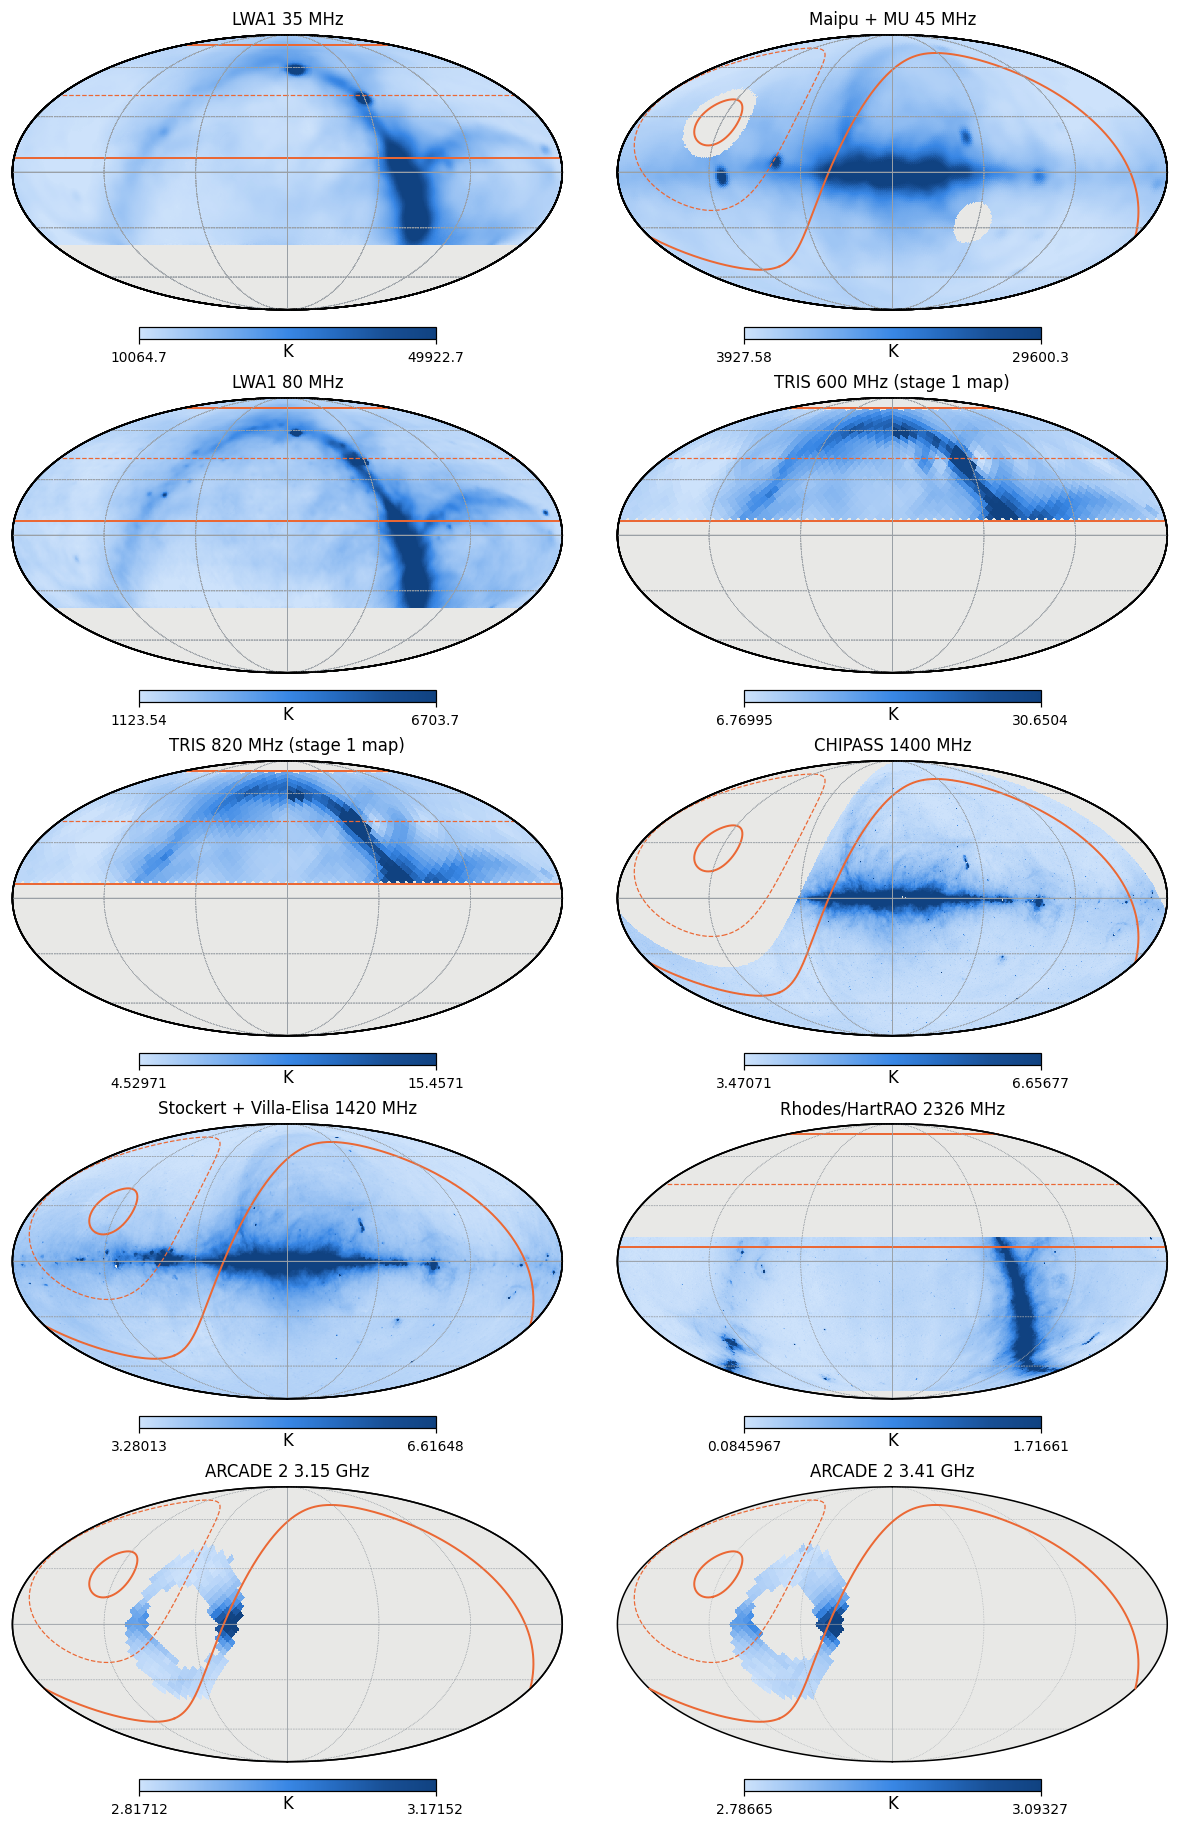

In [3]:
panels = [(m["name"], m["sky"], m["frame"]) for m in inp.fit_maps]
for f, name in zip((600, 820), TRIS_NAMES):
    panels.append((name, inp.stage1.band_map("sky_k", f), "C"))
panels.sort(key=lambda p: FREQ[p[0]])
rows = int(np.ceil(len(panels) / 2))
fig = plt.figure(figsize=(11, 3.3 * rows))
for k, (name, m, frame) in enumerate(panels):
    lo, hi = lims(m)
    hp.mollview(m, coord=frame, sub=(rows, 2, k + 1), fig=fig.number, cmap=SEQ, min=lo, max=hi,
                unit="K", title=f"{name}", **MKW)
    hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
    stripe_lines(frame)
save(fig, "fig01_maps_used")
plt.show()

---
## Figure 2 — The target and the TRIS stripe

Left: the destriped-only Haslam map at full resolution, drawn in equatorial (log scale),
with the stripe outlined. Right: the same map matched to the TRIS beam at nside 16, inside
the stripe only. This is the "old Haslam" the corrections are measured against.

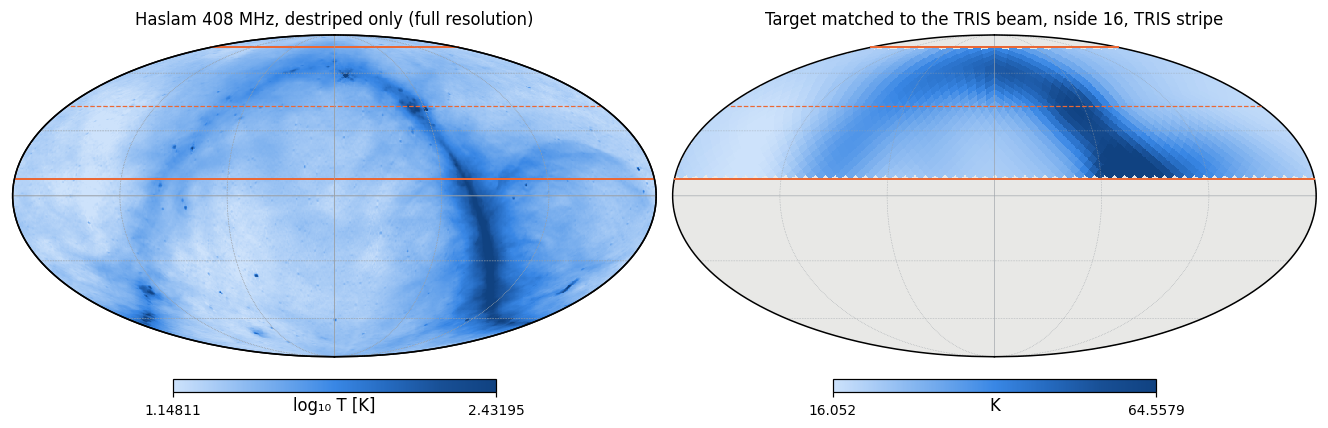

In [4]:
fig = plt.figure(figsize=(12, 3.9))
target = inp.target["sky"]
hp.mollview(np.log10(target), coord=["G", "C"], sub=(1, 2, 1), fig=fig.number, cmap=SEQ,
            min=np.log10(np.nanpercentile(target, 1)), max=np.log10(np.nanpercentile(target, 99.5)),
            unit="log₁₀ T [K]", title=f"{inp.target['name']} (full resolution)", **MKW)
hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
stripe_lines("C")
old = np.where(BAND, MR["old"], np.nan)
lo, hi = lims(old)
hp.mollview(old, coord="C", sub=(1, 2, 2), fig=fig.number, cmap=SEQ, min=lo, max=hi, unit="K",
            title="Target matched to the TRIS beam, nside 16, TRIS stripe", **MKW)
hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
stripe_lines("C")
save(fig, "fig02_target_stripe")
plt.show()

---
## Figure 3 — Slices along the TRIS stripe

Every map used in the fit, cut to the stripe's declinations (RA increasing to the left),
each sampled pixel by pixel at its own RA/Dec at native resolution. Grey: not observed.

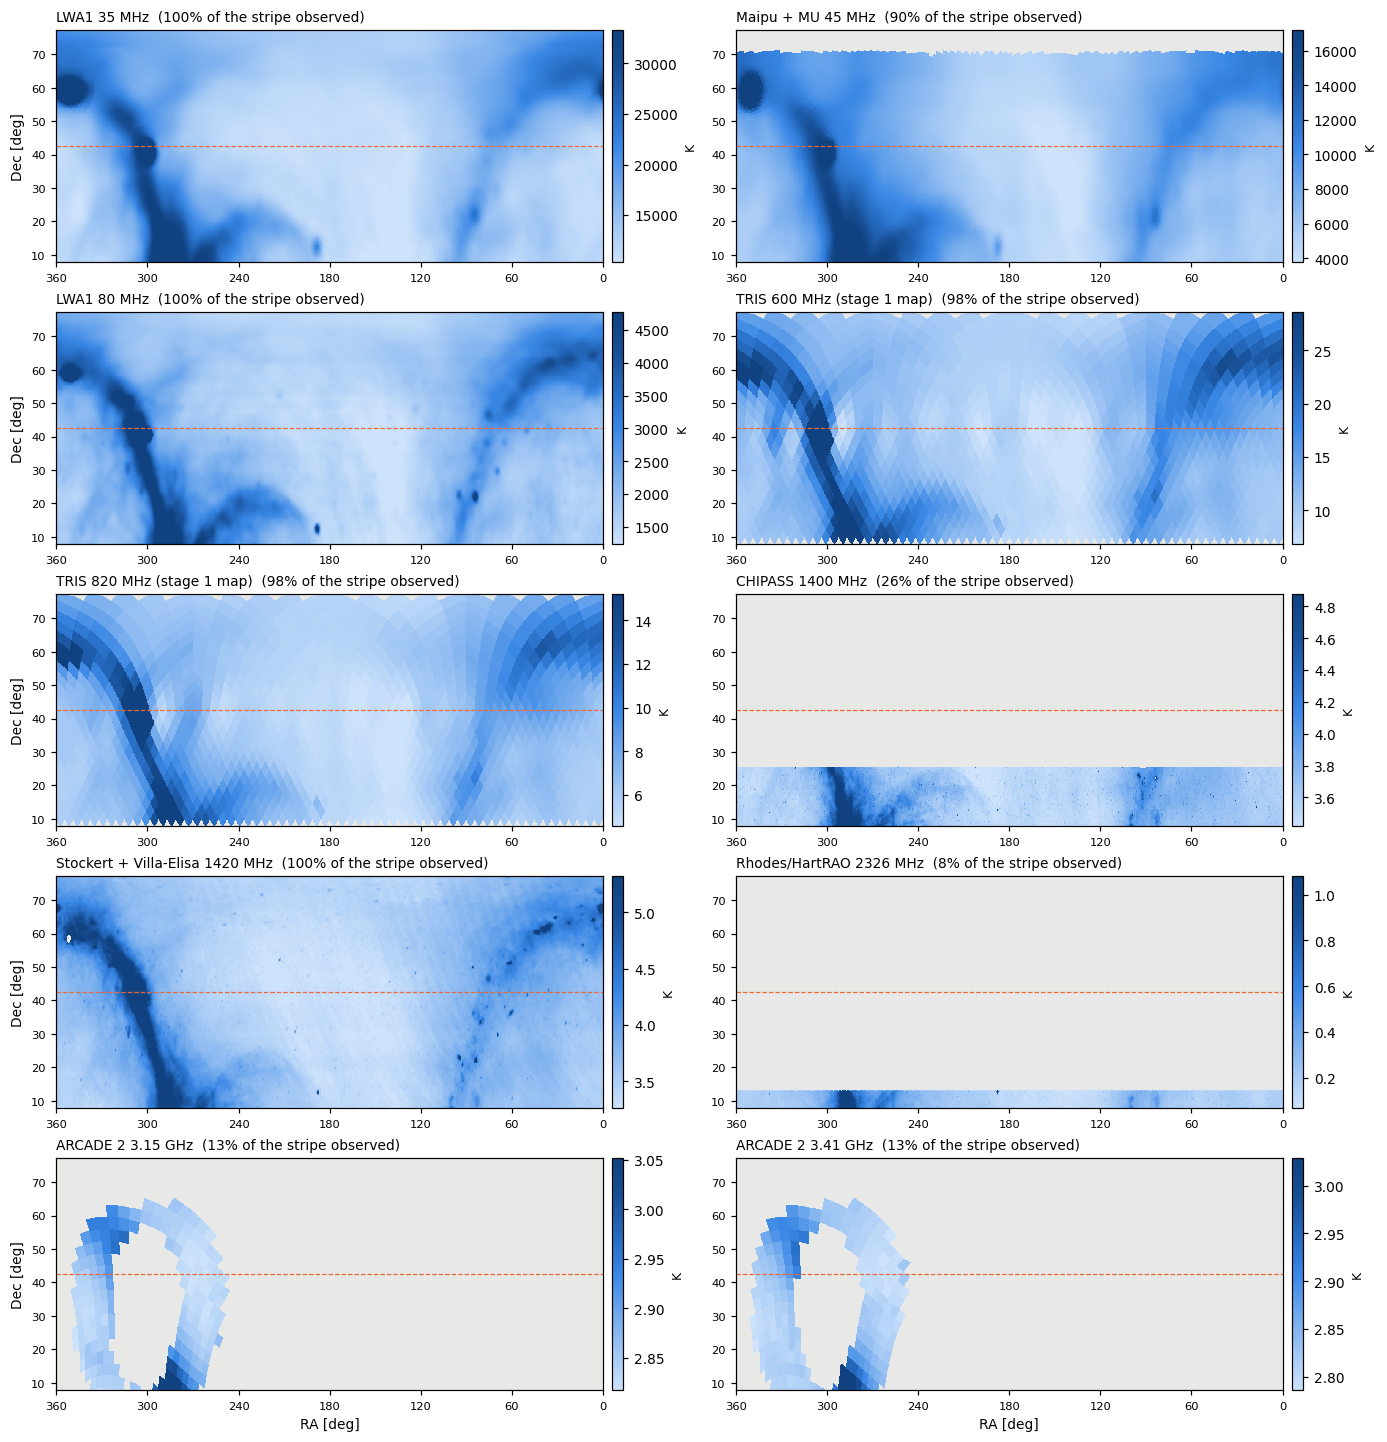

In [5]:
SL_RA = np.linspace(360, 0, 1441)
SL_DEC = np.linspace(STRIPE_DEC[0], STRIPE_DEC[1], 281)

def slice_image(m, frame):
    ra2, dec2 = np.meshgrid(SL_RA, SL_DEC)
    th, ph = np.radians(90 - dec2).ravel(), np.radians(ra2).ravel()
    if frame != "C":
        th, ph = hp.Rotator(coord=["C", frame])(th, ph)
    return m[hp.ang2pix(hp.get_nside(m), th, ph)].reshape(ra2.shape)

fig, axes = plt.subplots(rows, 2, figsize=(12.5, 2.6 * rows), squeeze=False, constrained_layout=True)
for ax, (name, m, frame) in zip(axes.flat, panels):
    img = slice_image(m, frame)
    seen = np.isfinite(img)
    lo, hi = (np.percentile(img[seen], [2, 98]) if seen.any() else (0, 1))
    im = ax.imshow(np.ma.masked_invalid(img), origin="lower", aspect="auto", cmap=SLICE,
                   vmin=lo, vmax=hi, interpolation="nearest",
                   extent=[360, 0, STRIPE_DEC[0], STRIPE_DEC[1]])
    ax.axhline(BORESIGHT, color="#eb6834", lw=0.8, ls="--")
    ax.set_title(f"{name}  ({100 * seen.mean():.0f}% of the stripe observed)", fontsize=9, loc="left")
    ax.set_xticks(np.arange(360, -1, -60)); ax.tick_params(labelsize=7.5)
    fig.colorbar(im, ax=ax, pad=0.01, fraction=0.04).set_label("K", fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("RA [deg]")
for ax in axes[:, 0]:
    ax.set_ylabel("Dec [deg]")
for ax in axes.flat[len(panels):]:
    ax.axis("off")
save(fig, "fig03_stripe_slices")
plt.show()

---
## Figure 4 — The TRIS maps regenerated from the rings, and their TODs

Top: stage 1's maps (limTOD's TOD → map Wiener filter). Below: the ring data, with error
bars that are the **published statistical uncertainties** from the archive, exactly as given.
The line is the model the map predicts for the same samples: the map seen through the TRIS
beam, plus the fitted zero level, $\sum_p B_{tp}\hat{x}_p + \hat{z}$. Underneath is the
residual, data − model (stage 1's `residual_k`).

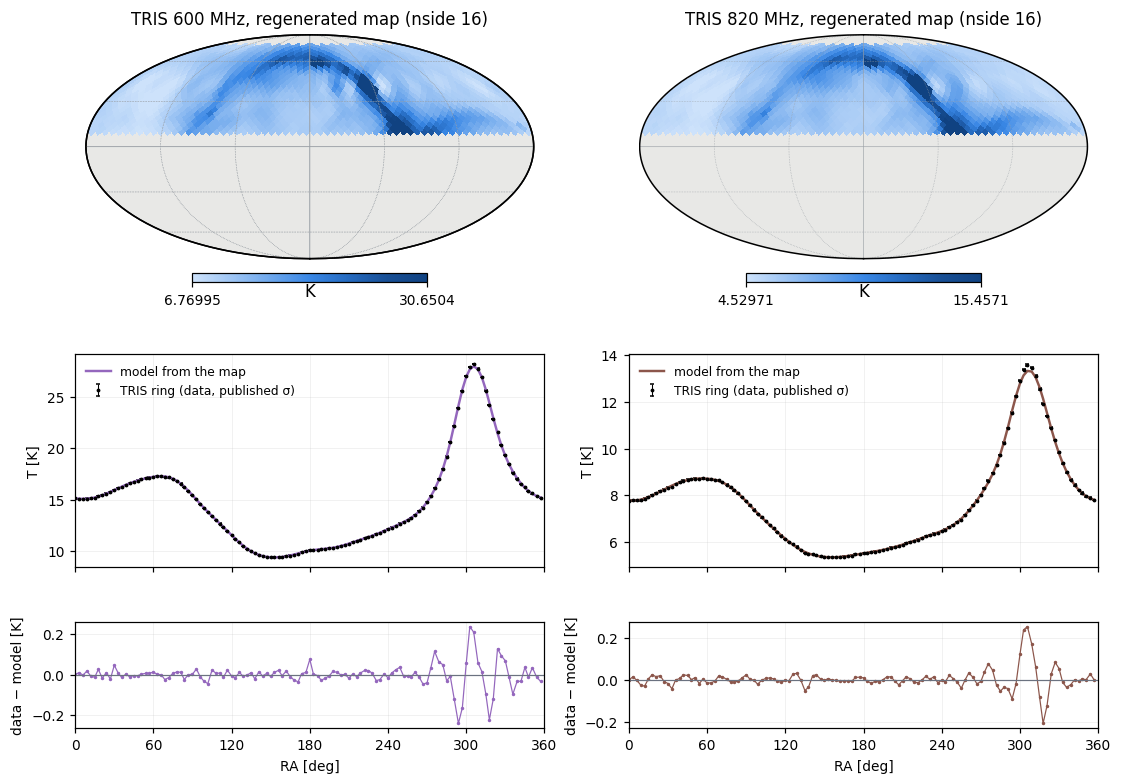

In [6]:
fig = plt.figure(figsize=(12, 8.2))
gs = fig.add_gridspec(3, 2, height_ratios=[1.25, 1, 0.5], hspace=0.28, wspace=0.18)
for col, f in enumerate((600, 820)):
    i = inp.stage1.index(f)
    ring = inp.rings[f]
    m = inp.stage1.band_map("sky_k", f)
    lo, hi = lims(m)
    plt.sca(fig.add_subplot(gs[0, col]))
    hp.mollview(m, coord="C", hold=True, cmap=SEQ, min=lo, max=hi, unit="K",
                title=f"TRIS {f} MHz, regenerated map (nside {NSIDE})", **MKW)
    hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
    data, resid = inp.stage1["data_k"][i], inp.stage1["residual_k"][i]
    ra = inp.stage1["ra_deg"][i]
    ax = fig.add_subplot(gs[1, col]); axr = fig.add_subplot(gs[2, col], sharex=ax)
    ax.errorbar(ra, data, yerr=np.asarray(ring.statistical_uncertainty_k), fmt=".", ms=3, color="k", elinewidth=0.7,
                capsize=1.5, label="TRIS ring (data, published σ)")
    ax.plot(ra, data - resid, "-", color=COLOUR[TRIS_NAMES[col]], lw=1.6, label="model from the map")
    ax.set_ylabel("T [K]"); ax.legend(fontsize=8, frameon=False)
    ax.tick_params(labelbottom=False)
    axr.plot(ra, resid, ".-", ms=2.5, lw=0.8, color=COLOUR[TRIS_NAMES[col]])
    axr.axhline(0, color="#6b7280", lw=0.8)
    axr.set_ylabel("data − model [K]"); axr.set_xlabel("RA [deg]")
    for a in (ax, axr):
        a.set_xlim(0, 360); a.set_xticks(np.arange(0, 361, 60)); a.grid(alpha=0.18, lw=0.6)
save(fig, "fig04_tris_maps_and_tods")
plt.show()

---
## Figure 5 — Pixel-by-pixel SED fits

Twelve stripe pixels across the range of sky brightness, four of them where ARCADE 2 is
available. Each panel shows the points with error bars (CMB removed, RJ), the best-fit power
law, and the target (open square: old Haslam, not fitted). Underneath is the residual,
(data − fit)/σ.

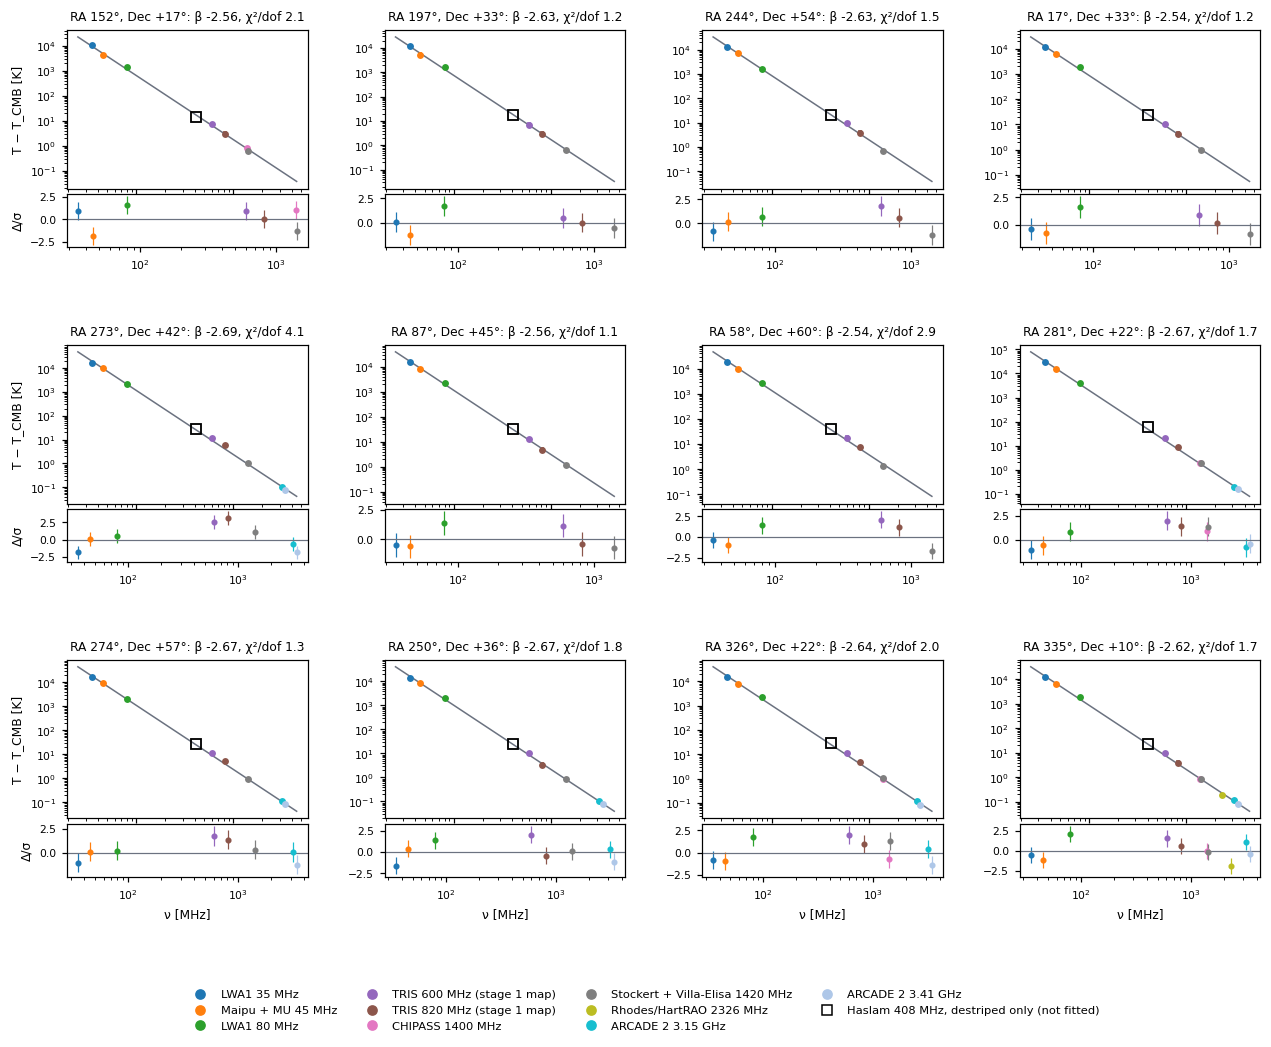

In [7]:
pts = MR["points"]
pix_all = np.array(sorted(pts))
old_vals = MR["old"][pix_all]
qs = np.percentile(old_vals, np.linspace(3, 97, 8))
choice = [pix_all[np.argmin(np.abs(old_vals - q))] for q in qs]
arc = [p for p in pix_all if any("ARCADE" in n for n in pts[p][3])]
choice += [arc[k] for k in np.linspace(0, len(arc) - 1, 4).astype(int)] if arc else []
choice = list(dict.fromkeys(choice))[:12]

cmb408 = sky_maps.cmb_rj_k(sp.NU0_MHZ)
fig = plt.figure(figsize=(14, 10))
outer = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.32)
grid_nu = np.geomspace(25, 4500, 200)
for k, p in enumerate(choice):
    nu, t, s, names, r = pts[p]
    inner = outer[k // 4, k % 4].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax, axr = fig.add_subplot(inner[0]), fig.add_subplot(inner[1])
    for n_, t_, s_, name in zip(nu, t, s, names):
        ax.errorbar(n_, t_, yerr=s_, fmt="o", ms=3.5, color=COLOUR[name], elinewidth=1, capsize=1.5)
        axr.errorbar(n_, (t_ - sp.power_law(n_, r["A"], r["beta"])) / s_, yerr=1, fmt="o", ms=3,
                     color=COLOUR[name], elinewidth=0.8)
    ax.plot(grid_nu, sp.power_law(grid_nu, r["A"], r["beta"]), "-", color="#6b7280", lw=1)
    ax.plot(408, MR["old"][p] - cmb408, "s", mfc="none", mec="k", ms=6, mew=1.2)
    ax.set_xscale("log"); ax.set_yscale("log"); axr.set_xscale("log")
    ra_p, dec_p = hp.pix2ang(NSIDE, p, lonlat=True)
    ax.set_title(f"RA {ra_p:.0f}°, Dec {dec_p:+.0f}°: β {r['beta']:.2f}, χ²/dof {r['chi2_dof']:.1f}",
                 fontsize=8)
    ax.tick_params(labelbottom=False, labelsize=7); axr.tick_params(labelsize=7)
    axr.axhline(0, color="#6b7280", lw=0.8)
    if k % 4 == 0:
        ax.set_ylabel("T − T_CMB [K]", fontsize=8); axr.set_ylabel("Δ/σ", fontsize=8)
    if k // 4 == 2:
        axr.set_xlabel("ν [MHz]", fontsize=8)
handles = [plt.Line2D([], [], marker="o", ls="", color=COLOUR[n], label=n) for n in ORDER if n != inp.target["name"]]
handles.append(plt.Line2D([], [], marker="s", ls="", mfc="none", mec="k", label=f"{inp.target['name']} (not fitted)"))
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=7.5, frameon=False, bbox_to_anchor=(0.5, -0.04))
save(fig, "fig05_sed_fits")
plt.show()

---
## Figure 5b — Sample-by-sample SED fits (TOD route)

The same fit along the TRIS ring. Twelve of the 120 samples, spread in RA, four of them
where ARCADE 2 reaches the beam (RA ≈ 255–342°). The points are the real TRIS ring data and
every map's TOD as limTOD observes it through the TRIS beam (CMB removed, RJ), with the
best-fit power law. The open square is old Haslam's TOD at that sample (not fitted).
Underneath is the residual, (data − fit)/σ.

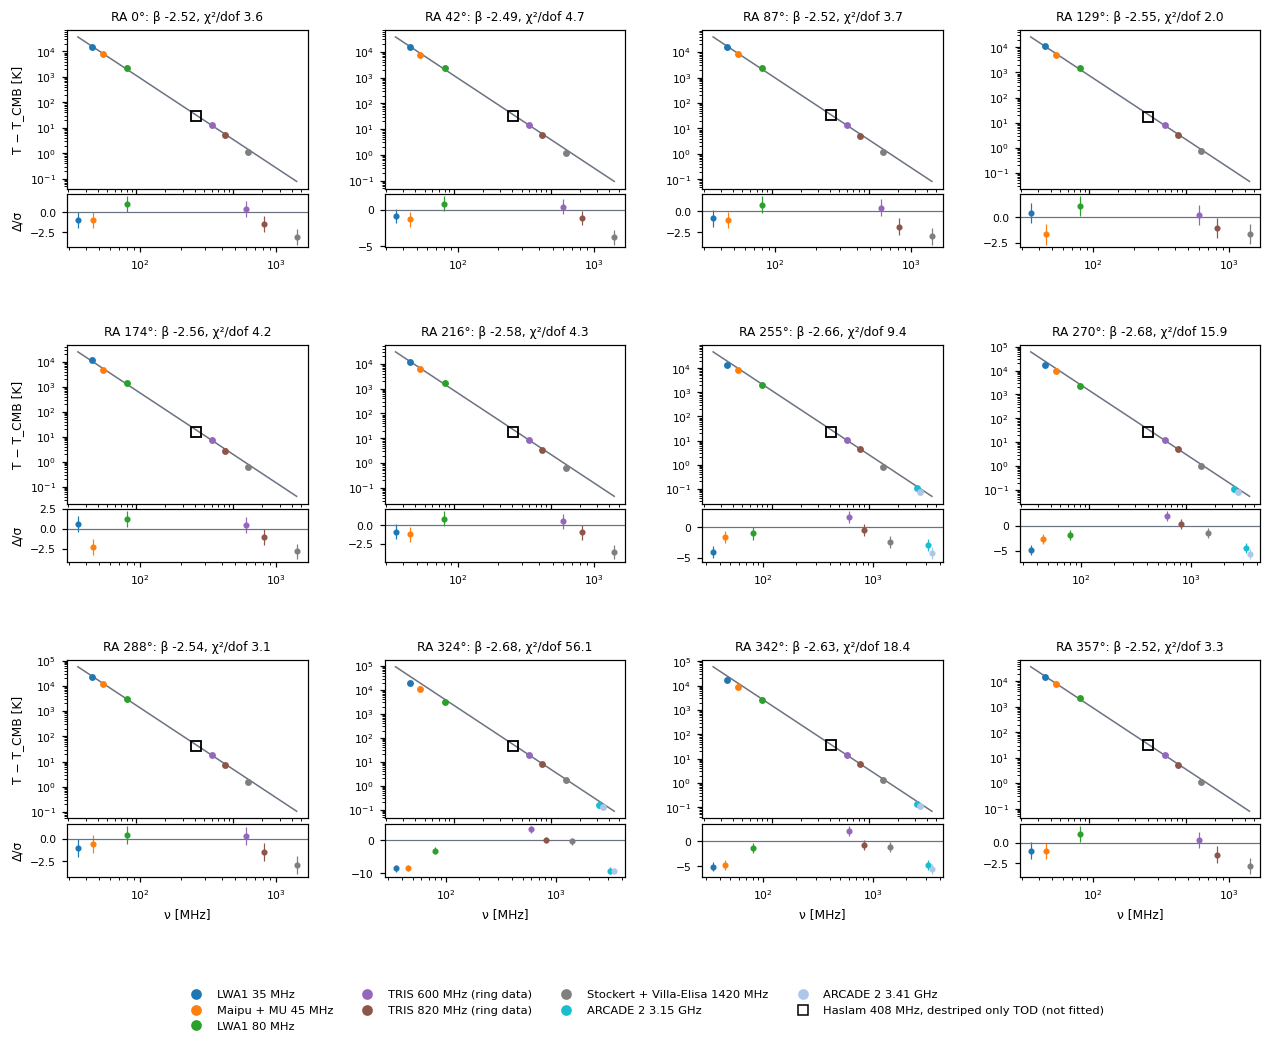

In [8]:
tpts = TR["points"]
def colour_of(name):
    # Ring data share the TRIS colours used for the stage 1 maps.
    if name.startswith("TRIS 600"):
        return COLOUR[TRIS_NAMES[0]]
    if name.startswith("TRIS 820"):
        return COLOUR[TRIS_NAMES[1]]
    return COLOUR[name]

samples = sorted(tpts)
with_arc = [k for k in samples if any("ARCADE" in n for n in tpts[k][3])]
without = [k for k in samples if k not in with_arc]
pick = [without[i] for i in np.linspace(0, len(without) - 1, 8).astype(int)]
pick += [with_arc[i] for i in np.linspace(0, len(with_arc) - 1, 4).astype(int)] if with_arc else []
pick = sorted(dict.fromkeys(pick), key=lambda k: inp.ra[k])[:12]

fig = plt.figure(figsize=(14, 10))
outer = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.32)
for k, t_idx in enumerate(pick):
    nu, t, s, names_t, r = tpts[t_idx]
    inner = outer[k // 4, k % 4].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax, axr = fig.add_subplot(inner[0]), fig.add_subplot(inner[1])
    for n_, t_, s_, name in zip(nu, t, s, names_t):
        c = colour_of(name)
        ax.errorbar(n_, t_, yerr=s_, fmt="o", ms=3.5, color=c, elinewidth=1, capsize=1.5)
        axr.errorbar(n_, (t_ - sp.power_law(n_, r["A"], r["beta"])) / s_, yerr=1, fmt="o", ms=3,
                     color=c, elinewidth=0.8)
    ax.plot(grid_nu, sp.power_law(grid_nu, r["A"], r["beta"]), "-", color="#6b7280", lw=1)
    ax.plot(408, TR["target_tod"][t_idx] - cmb408, "s", mfc="none", mec="k", ms=6, mew=1.2)
    ax.set_xscale("log"); ax.set_yscale("log"); axr.set_xscale("log")
    ax.set_title(f"RA {inp.ra[t_idx]:.0f}°: β {r['beta']:.2f}, χ²/dof {r['chi2_dof']:.1f}", fontsize=8)
    ax.tick_params(labelbottom=False, labelsize=7); axr.tick_params(labelsize=7)
    axr.axhline(0, color="#6b7280", lw=0.8)
    if k % 4 == 0:
        ax.set_ylabel("T − T_CMB [K]", fontsize=8); axr.set_ylabel("Δ/σ", fontsize=8)
    if k // 4 == 2:
        axr.set_xlabel("ν [MHz]", fontsize=8)
used = sorted({n for t_idx in pick for n in tpts[t_idx][3]}, key=lambda n: FREQ.get(n, 600.5 if "600" in n else 817.8))
handles = [plt.Line2D([], [], marker="o", ls="", color=colour_of(n), label=n) for n in used]
handles.append(plt.Line2D([], [], marker="s", ls="", mfc="none", mec="k", label=f"{inp.target['name']} TOD (not fitted)"))
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=7.5, frameon=False, bbox_to_anchor=(0.5, -0.04))
save(fig, "fig05b_sed_fits_tod")
plt.show()

---
## Figure 6 — Best fit − map, every map used

$T_\mathrm{best\,fit} - T_\mathrm{map}$, in kelvin, over the TRIS stripe, for every map that
entered the per-pixel fit (map route). Both are Rayleigh-Jeans temperatures with the CMB
removed, at that survey's own frequency. Positive (red) means the best-fit power law lies
above that survey's map at that pixel. A survey that sits consistently above or below the
common power law shows as one colour. The surveys span ~0.1 K to ~10⁴ K, so **each panel
has its own colour scale**, symmetric about zero. Each map's median is printed under the
figure.

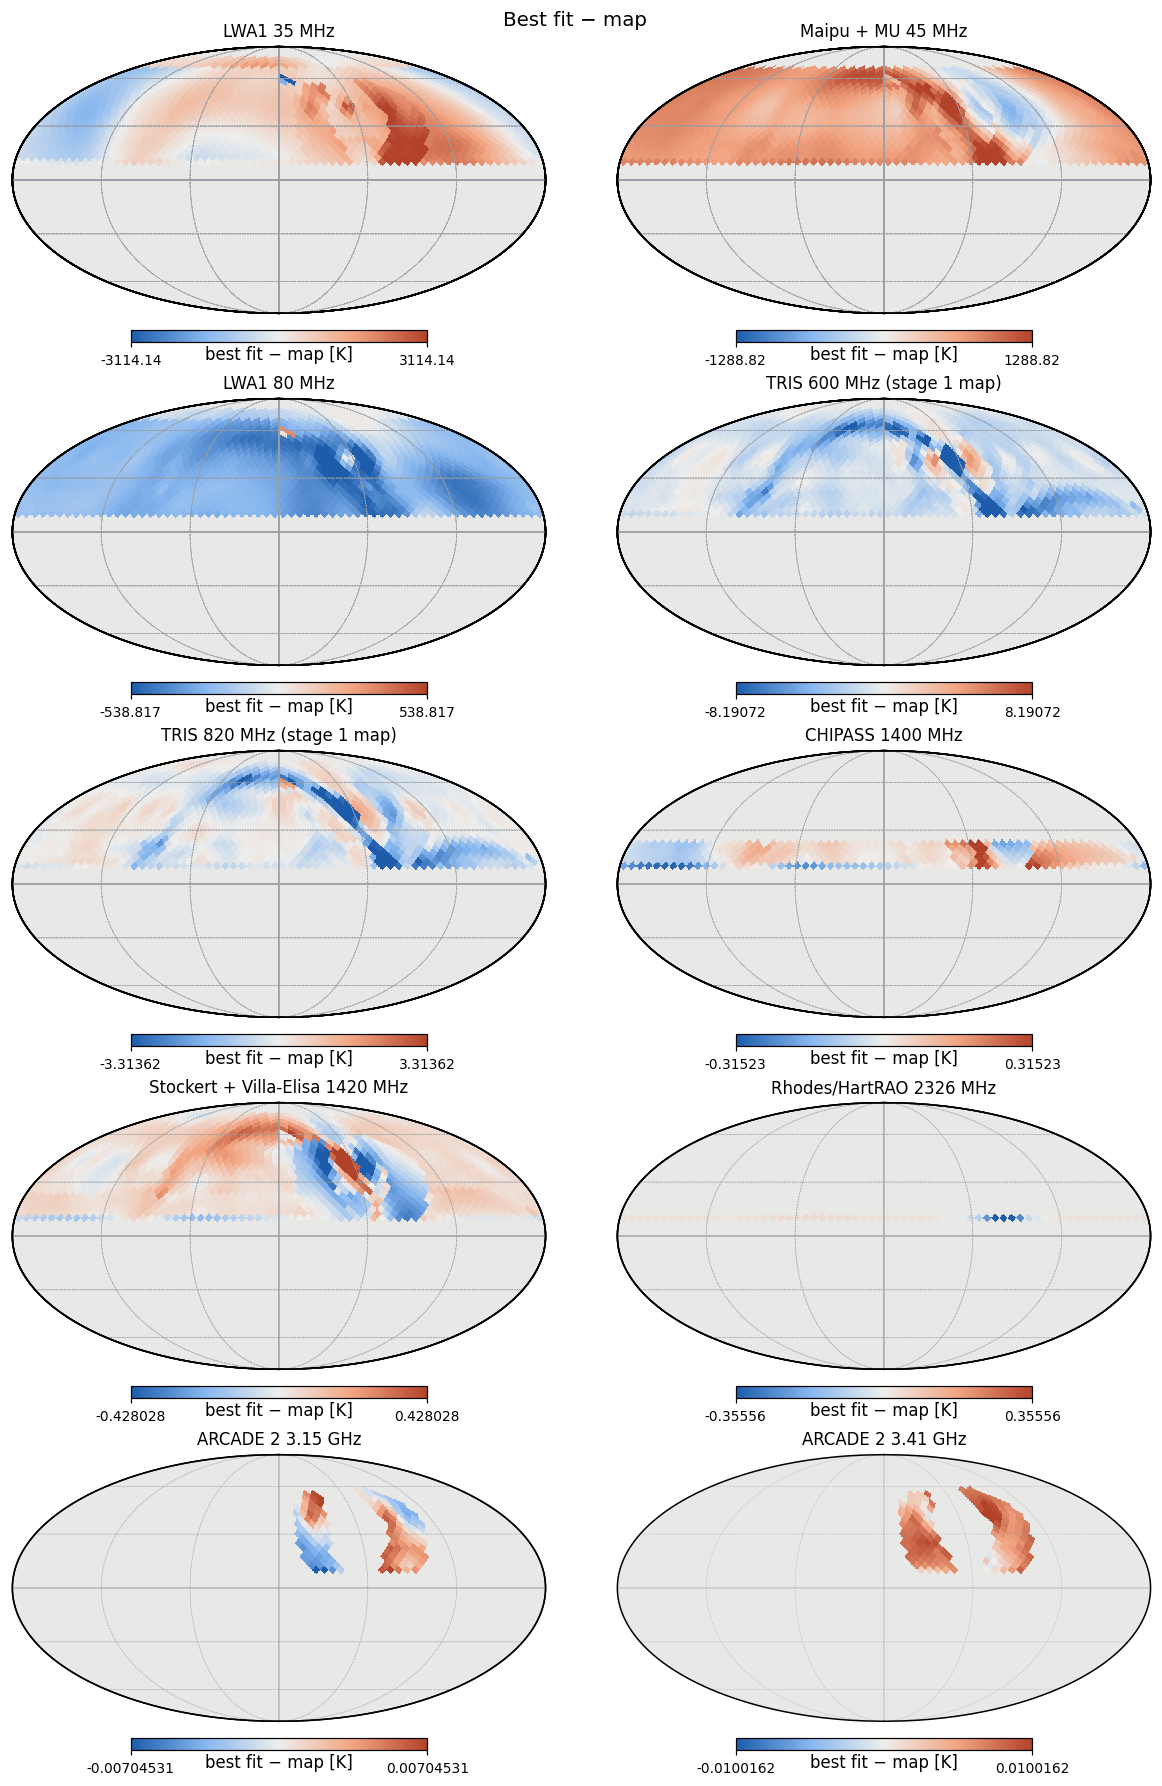

map                                   median best fit − map [K]                16–84% [K]  pixels
LWA1 35 MHz                                              +553.6             -516 to +1489    1272
Maipu + MU 45 MHz                                        +660.2            +253 to +840.2    1200
LWA1 80 MHz                                              -265.1            -399 to -207.6    1272
TRIS 600 MHz (stage 1 map)                                -1.21         -2.964 to -0.2999    1272
TRIS 820 MHz (stage 1 map)                              -0.1246        -0.9251 to +0.2438    1272
CHIPASS 1400 MHz                                       +0.02635        -0.08287 to +0.112     382
Stockert + Villa-Elisa 1420 MHz                        +0.05042       -0.06493 to +0.1102    1269
Rhodes/HartRAO 2326 MHz                                +0.03055     -0.009936 to +0.04331      64
ARCADE 2 3.15 GHz                                     +0.001114    -0.003409 to +0.004876     153
ARCADE 2 3.41 GHz   

In [9]:
names = [n for n in ORDER if n in MR["fit_minus_map"]]
rows6 = int(np.ceil(len(names) / 2))
fig = plt.figure(figsize=(11, 3.2 * rows6))
for k, name in enumerate(names):
    r = MR["fit_minus_map"][name]                 # K, RJ, CMB removed
    span = float(np.nanpercentile(np.abs(r), 98)) or 1.0
    hp.mollview(r, coord="C", sub=(rows6, 2, k + 1), fig=fig.number, cmap=DIV, min=-span, max=span,
                unit="best fit − map [K]", title=name, **MKW)
    hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
fig.suptitle("Best fit − map", fontsize=13, y=1.0)
save(fig, "fig06_fit_residual_maps")
plt.show()

print(f"{'map':<36}{'median best fit − map [K]':>27}{'16–84% [K]':>26}{'pixels':>8}")
for name in names:
    r = MR["fit_minus_map"][name]
    lo16, hi84 = np.nanpercentile(r, [16, 84])
    print(f"{name:<36}{np.nanmedian(r):+27.4g}{f'{lo16:+.4g} to {hi84:+.4g}':>26}{int(np.isfinite(r).sum()):8d}")

---
## Figure 6b — Best fit − data, TOD route

The TOD-route counterpart of Figure 6: at each of the 120 ring samples, the best-fit power
law minus each survey's value, in kelvin, against RA. TRIS 600 and 820 MHz are the real ring
data; the other surveys are their simulated TRIS TODs. A survey appears only at samples
where at least half of the TRIS beam falls on its observed sky. Each panel has its own
vertical scale. Medians are printed under the figure.

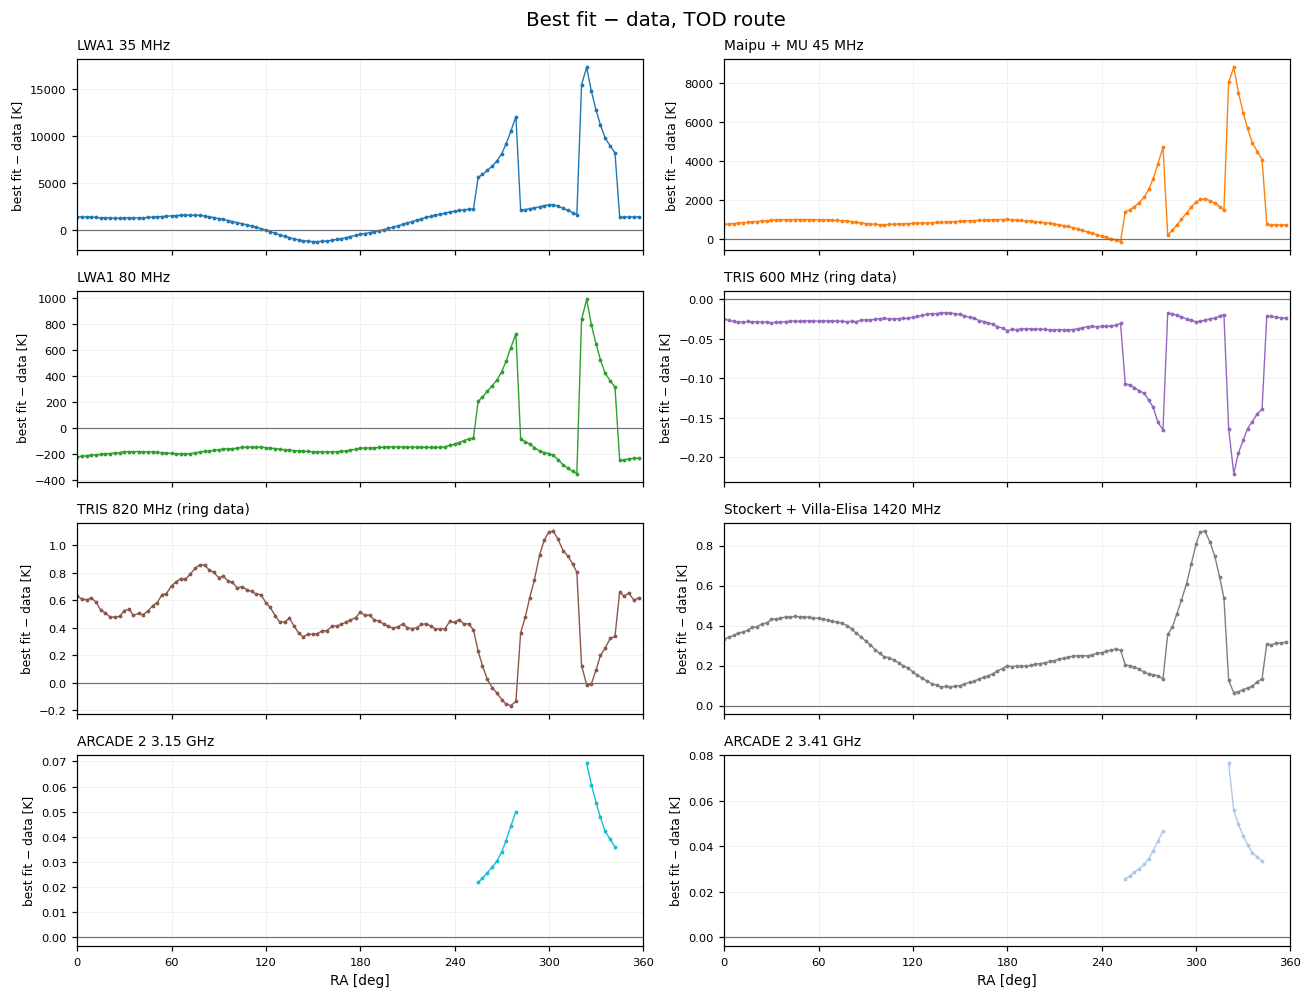

TOD                                   median best fit − data [K]                16–84% [K]  samples
LWA1 35 MHz                                                +1336           -380.7 to +2567      120
Maipu + MU 45 MHz                                         +934.5           +751.8 to +1679      120
LWA1 80 MHz                                               -167.9          -200.8 to -86.69      120
TRIS 600 MHz (ring data)                                -0.02804      -0.03864 to -0.02262      120
TRIS 820 MHz (ring data)                                 +0.4824        +0.3546 to +0.7486      120
Stockert + Villa-Elisa 1420 MHz                          +0.2494        +0.1332 to +0.4358      120
ARCADE 2 3.15 GHz                                       +0.03879       +0.02664 to +0.0522       16
ARCADE 2 3.41 GHz                                       +0.03718        +0.02956 to +0.048       17


In [10]:
resid_t = {}
for k, (nu, t, s, names_t, r) in TR["points"].items():
    for n_, t_, name in zip(nu, t, names_t):
        resid_t.setdefault(name, np.full(inp.ra.size, np.nan))[k] = sp.power_law(n_, r["A"], r["beta"]) - t_
order_t = sorted(resid_t, key=lambda n: FREQ.get(n, 600.5 if n.startswith("TRIS 600") else 817.8))
rows_t = int(np.ceil(len(order_t) / 2))
fig, axes = plt.subplots(rows_t, 2, figsize=(12, 2.3 * rows_t), sharex=True, squeeze=False)
for ax, name in zip(axes.flat, order_t):
    ax.plot(inp.ra, resid_t[name], ".-", ms=3, lw=0.9, color=colour_of(name))
    ax.axhline(0, color="#6b7280", lw=0.8)
    ax.set_title(name, fontsize=9, loc="left")
    ax.set_ylabel("best fit − data [K]", fontsize=8)
    ax.set_xlim(0, 360); ax.set_xticks(np.arange(0, 361, 60)); ax.grid(alpha=0.18, lw=0.6)
    ax.tick_params(labelsize=7.5)
for ax in axes.flat[len(order_t):]:
    ax.axis("off")
for ax in axes[-1]:
    ax.set_xlabel("RA [deg]")
fig.suptitle("Best fit − data, TOD route", fontsize=13)
fig.tight_layout()
save(fig, "fig06b_tod_residuals")
plt.show()

print(f"{'TOD':<36}{'median best fit − data [K]':>28}{'16–84% [K]':>26}{'samples':>9}")
for name in order_t:
    r = resid_t[name]
    lo16, hi84 = np.nanpercentile(r, [16, 84])
    print(f"{name:<36}{np.nanmedian(r):+28.4g}{f'{lo16:+.4g} to {hi84:+.4g}':>26}{int(np.isfinite(r).sum()):9d}")

---
## Figure 7 — Best-fit Haslam from both routes, and the difference from old Haslam

Top: the best-fit 408 MHz Haslam over the TRIS stripe, from the map route (per-pixel fit)
and from the TOD route (old Haslam plus the ring correction mapped by the Wiener filter),
on one colour scale. Bottom: each minus old Haslam, on one shared symmetric scale.

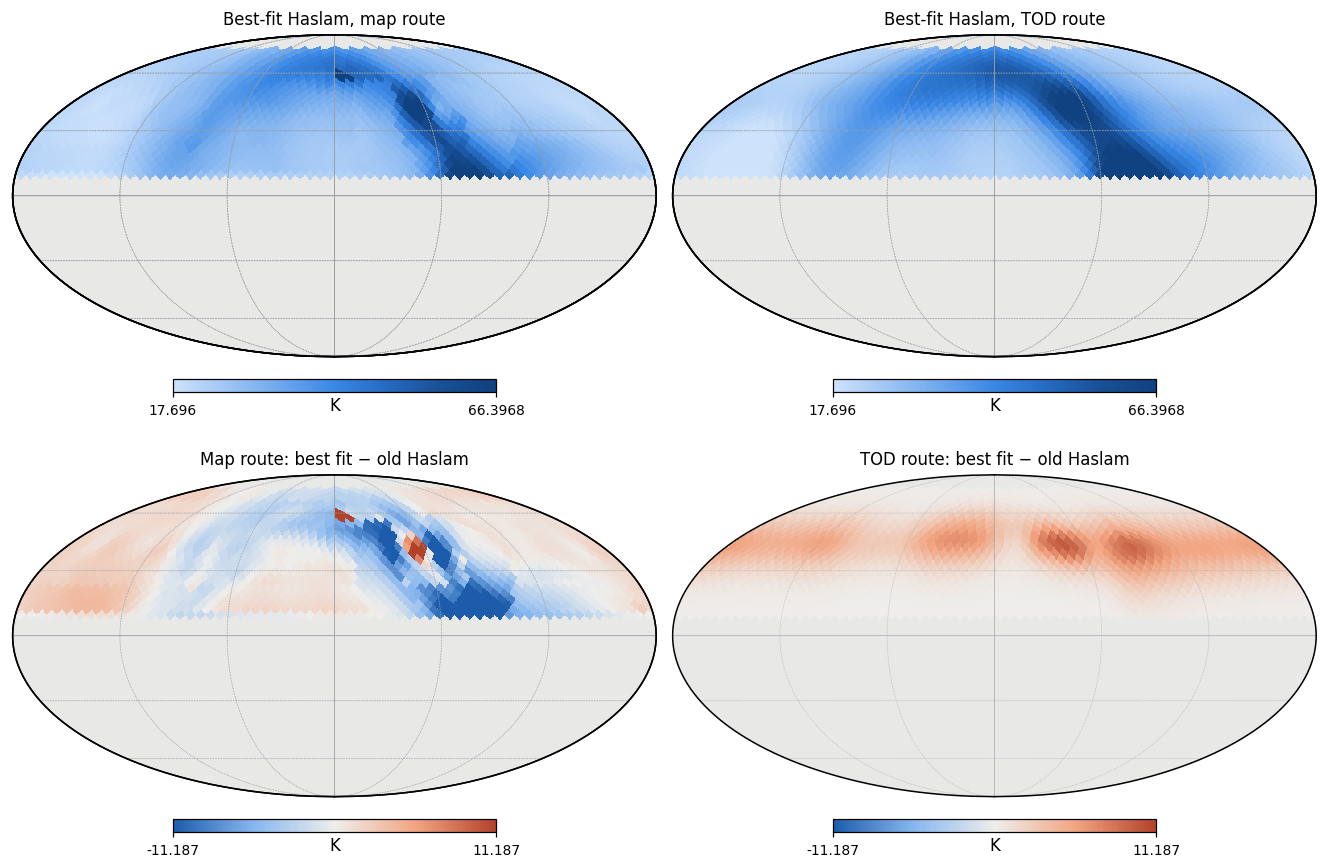

map route: best fit − old median -0.13 K (-0.4%) over 1272 pixels
TOD route: best fit − old median +1.35 K (+4.3%) over 1272 pixels


In [11]:
inb = BAND & np.isfinite(MR["pred"])
best_map = np.where(inb, MR["pred"], np.nan)
best_tod = np.where(BAND, TR["pred_map"], np.nan)
d_map = best_map - MR["old"]
d_tod = np.where(BAND, TR["delta"], np.nan)
lo, hi = np.nanpercentile(np.concatenate([best_map, best_tod]), [2, 98])
span_d = float(np.nanpercentile(np.abs(np.concatenate([d_map, d_tod])), 98))
fig = plt.figure(figsize=(12, 8.0))
for k, (title, m, cmap, a, b) in enumerate([
        ("Best-fit Haslam, map route", best_map, SEQ, lo, hi),
        ("Best-fit Haslam, TOD route", best_tod, SEQ, lo, hi),
        ("Map route: best fit − old Haslam", d_map, DIV, -span_d, span_d),
        ("TOD route: best fit − old Haslam", d_tod, DIV, -span_d, span_d)]):
    hp.mollview(m, coord="C", sub=(2, 2, k + 1), fig=fig.number, cmap=cmap, min=a, max=b, unit="K",
                title=title, **MKW)
    hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
save(fig, "fig07_bestfit_haslam_both_routes")
plt.show()
print(f"map route: best fit − old median {np.nanmedian(d_map):+.2f} K "
      f"({100 * np.nanmedian(d_map / MR['old']):+.1f}%) over {int(inb.sum())} pixels")
print(f"TOD route: best fit − old median {np.nanmedian(d_tod):+.2f} K "
      f"({100 * np.nanmedian(d_tod / MR['old']):+.1f}%) over {int(np.isfinite(d_tod).sum())} pixels")

---
## Figure 7b — The TOD route along the ring

Old Haslam's simulated TRIS TOD and the best-fit 408 MHz prediction (±1σ band) at each of
the 120 ring samples, with their difference below.

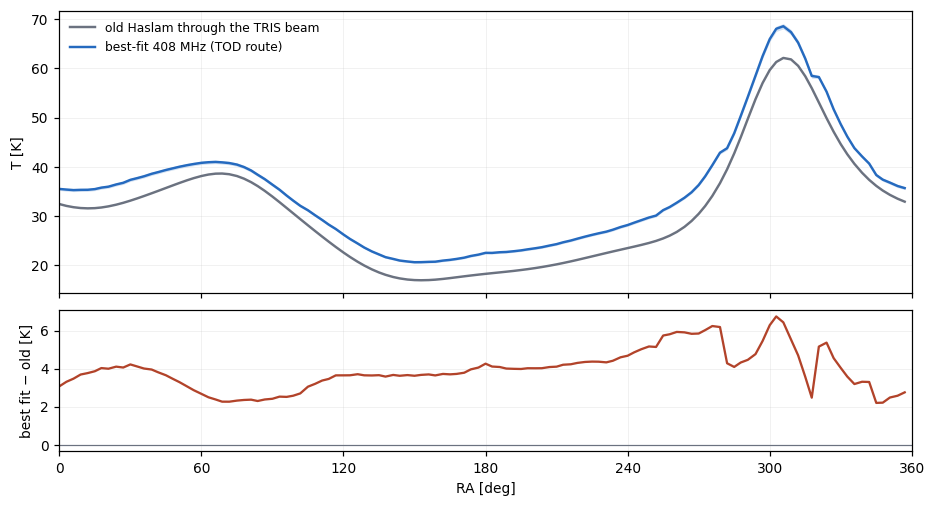

along the ring: best fit − old median +3.84 K (+12.6%)


In [12]:
fig, (ax, axd) = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True, gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))
ax.plot(inp.ra, TR["target_tod"], "-", color="#6b7280", lw=1.6, label="old Haslam through the TRIS beam")
ax.plot(inp.ra, TR["pred"], "-", color="#256abf", lw=1.6, label="best-fit 408 MHz (TOD route)")
ax.fill_between(inp.ra, TR["pred"] - TR["sigma_pred"], TR["pred"] + TR["sigma_pred"], color="#256abf", alpha=0.2, lw=0)
ax.set_ylabel("T [K]"); ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.18, lw=0.6)
axd.plot(inp.ra, TR["delta_tod"], "-", color="#b2432a", lw=1.5)
axd.axhline(0, color="#6b7280", lw=0.8)
axd.set_ylabel("best fit − old [K]"); axd.set_xlabel("RA [deg]"); axd.grid(alpha=0.18, lw=0.6)
axd.set_xlim(0, 360); axd.set_xticks(np.arange(0, 361, 60))
save(fig, "fig07b_tod_route_ring")
plt.show()
print(f"along the ring: best fit − old median {np.nanmedian(TR['delta_tod']):+.2f} K "
      f"({100 * np.nanmedian(TR['delta_tod'] / TR['target_tod']):+.1f}%)")

---
## Figure 7c — (Best fit − old)/old, both routes

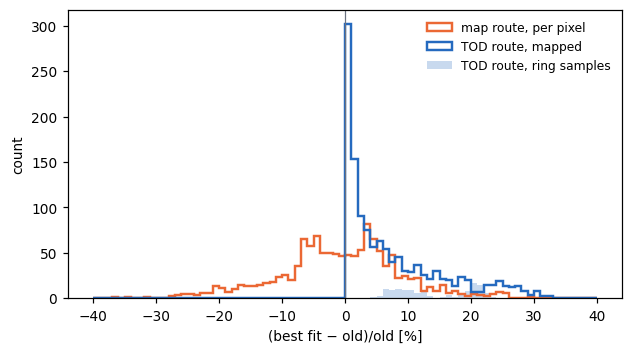

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
bins = np.linspace(-40, 40, 81)
ax.hist(100 * d_map[inb] / MR["old"][inb], bins=bins, histtype="step", lw=1.6, color="#eb6834",
        label="map route, per pixel")
ax.hist(100 * d_tod[BAND] / MR["old"][BAND], bins=bins, histtype="step", lw=1.6, color="#256abf",
        label="TOD route, mapped")
ax.hist(100 * TR["delta_tod"] / TR["target_tod"], bins=bins, histtype="stepfilled", alpha=0.25,
        color="#256abf", label="TOD route, ring samples")
ax.axvline(0, color="#6b7280", lw=0.8)
ax.set_xlabel("(best fit − old)/old [%]"); ax.set_ylabel("count"); ax.legend(fontsize=8, frameon=False)
save(fig, "fig07c_fractional_difference_hist")
plt.show()

---
## Figure 8 — Pixel-by-pixel residuals, every pixel

The residual $(T_\mathrm{data} - T_\mathrm{fit})/\sigma$ of every survey at every stripe
pixel (map route), against frequency. Boxes show the 25–75% range; whiskers the 5–95%.

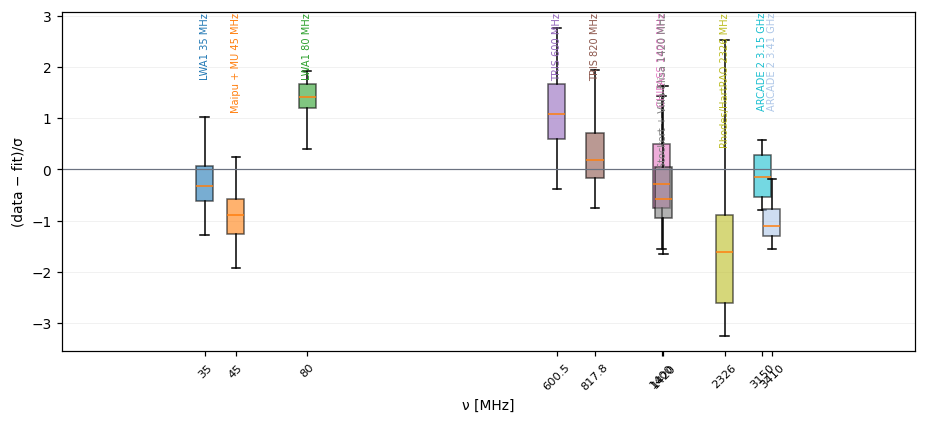

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
data, pos, cols = [], [], []
for name in names:
    v = MR["resid_norm"][name]
    v = v[np.isfinite(v)]
    data.append(v); pos.append(np.log10(FREQ[name])); cols.append(COLOUR[name])
bp = ax.boxplot(data, positions=pos, widths=0.06, whis=(5, 95), showfliers=False, patch_artist=True)
for patch, c in zip(bp["boxes"], cols):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axhline(0, color="#6b7280", lw=0.8)
ax.set_xticks(pos); ax.set_xticklabels([f"{FREQ[n]:g}" for n in names], rotation=45, fontsize=7.5)
ax.set_xlabel("ν [MHz]"); ax.set_ylabel("(data − fit)/σ")
ax.grid(alpha=0.18, lw=0.6, axis="y")
for name, x in zip(names, pos):
    ax.text(x, ax.get_ylim()[1], name.split(" (")[0], rotation=90, fontsize=6.5, va="top", ha="center", color=COLOUR[name])
save(fig, "fig08_residuals_by_survey")
plt.show()

---
## Figure 9 — χ² maps

χ²/dof of the per-pixel fit and the number of points behind it (map route), and χ²/dof
along the ring (TOD route). Five surveys carry an assumed 10% error, so χ² is indicative.

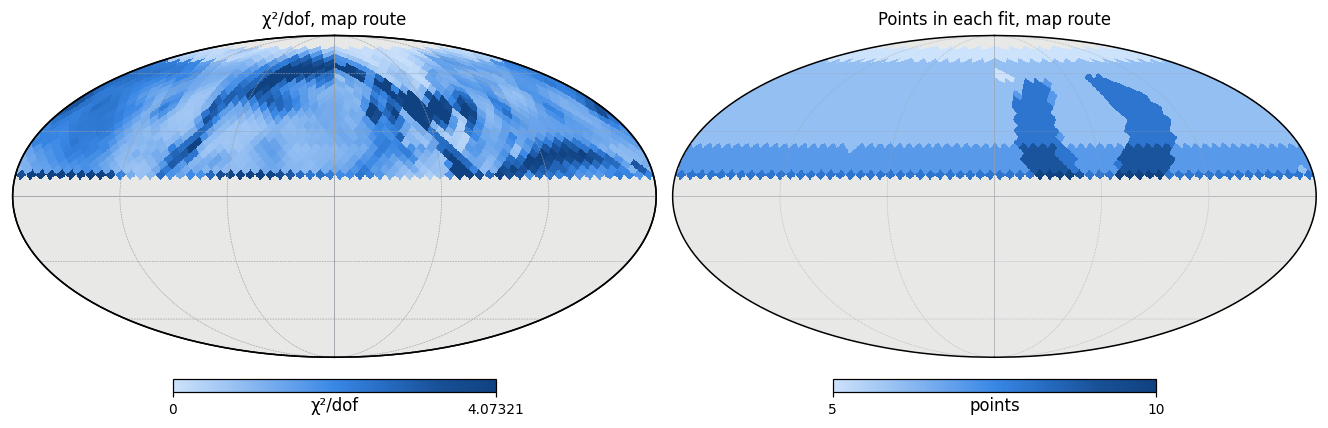

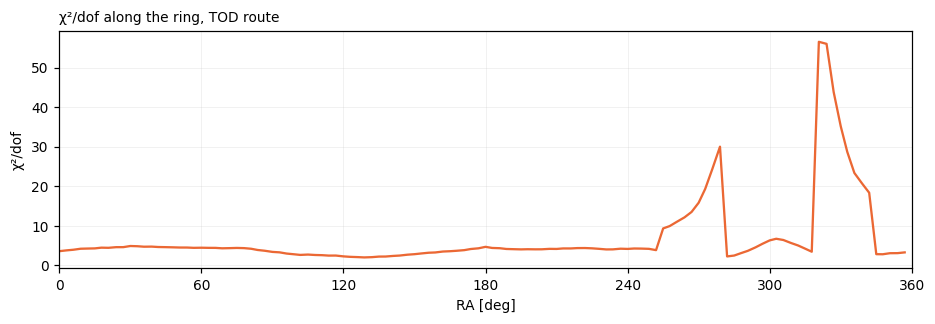

In [15]:
fig = plt.figure(figsize=(12, 3.8))
hp.mollview(MR["chi2_dof"], coord="C", sub=(1, 2, 1), fig=fig.number, cmap=SEQ, min=0,
            max=float(np.nanpercentile(MR["chi2_dof"], 95)), unit="χ²/dof", title="χ²/dof, map route", **MKW)
hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
hp.mollview(MR["n"], coord="C", sub=(1, 2, 2), fig=fig.number, cmap=SEQ, min=np.nanmin(MR["n"]),
            max=np.nanmax(MR["n"]), unit="points", title="Points in each fit, map route", **MKW)
hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
save(fig, "fig09a_chi2_maps")
plt.show()
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(inp.ra, TR["chi2_dof"], "-", color="#eb6834", lw=1.5)
ax.set_xlabel("RA [deg]"); ax.set_ylabel("χ²/dof"); ax.set_xlim(0, 360); ax.set_xticks(np.arange(0, 361, 60))
ax.set_title("χ²/dof along the ring, TOD route", fontsize=9, loc="left"); ax.grid(alpha=0.18, lw=0.6)
save(fig, "fig09b_chi2_tod")
plt.show()

---
## Figure 10 — β maps

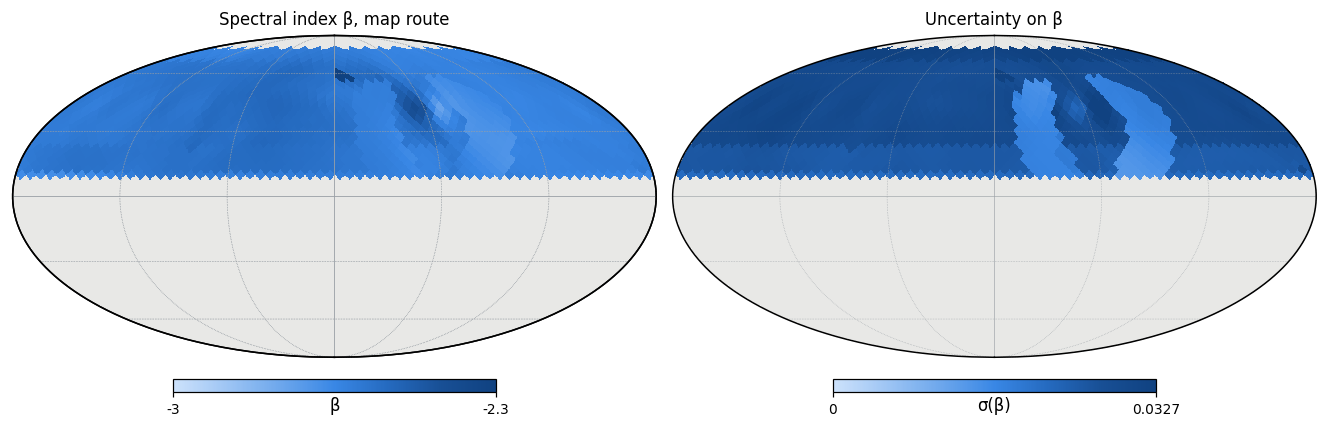

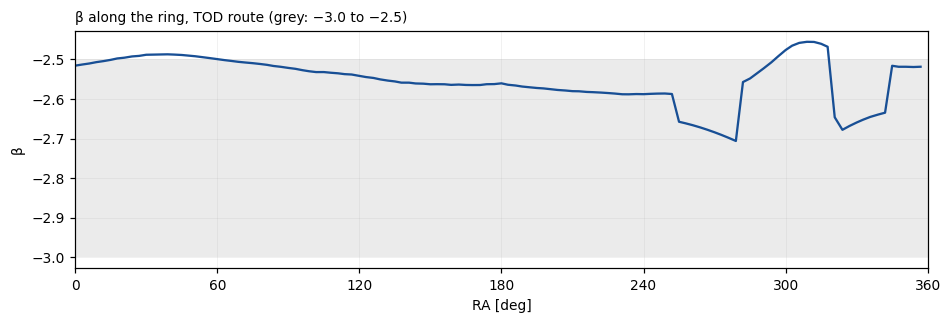

In [16]:
fig = plt.figure(figsize=(12, 3.8))
hp.mollview(MR["beta"], coord="C", sub=(1, 2, 1), fig=fig.number, cmap=SEQ, min=-3.0, max=-2.3,
            unit="β", title="Spectral index β, map route", **MKW)
hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
hp.mollview(MR["sigma_beta"], coord="C", sub=(1, 2, 2), fig=fig.number, cmap=SEQ, min=0,
            max=float(np.nanpercentile(MR["sigma_beta"], 98)), unit="σ(β)", title="Uncertainty on β", **MKW)
hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
save(fig, "fig10a_beta_maps")
plt.show()
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(inp.ra, TR["beta"], "-", color="#184f95", lw=1.5)
ax.axhspan(-3.0, -2.5, color="0.92", lw=0, zorder=0)
ax.set_xlabel("RA [deg]"); ax.set_ylabel("β"); ax.set_xlim(0, 360); ax.set_xticks(np.arange(0, 361, 60))
ax.set_title("β along the ring, TOD route (grey: −3.0 to −2.5)", fontsize=9, loc="left"); ax.grid(alpha=0.18, lw=0.6)
save(fig, "fig10b_beta_tod")
plt.show()

---
## Figure 11 — The corrected Haslam at full resolution

The target at full resolution (nside 512), drawn in equatorial. Each route's nside 16
correction is interpolated smoothly onto the full-resolution grid and added **inside the
TRIS stripe**; outside, the map is the original. This applies a 23°-scale correction to a
56′ map, the uniform-per-patch first pass of stage 4. A visible step at the stripe edge is
the correction's own value there.

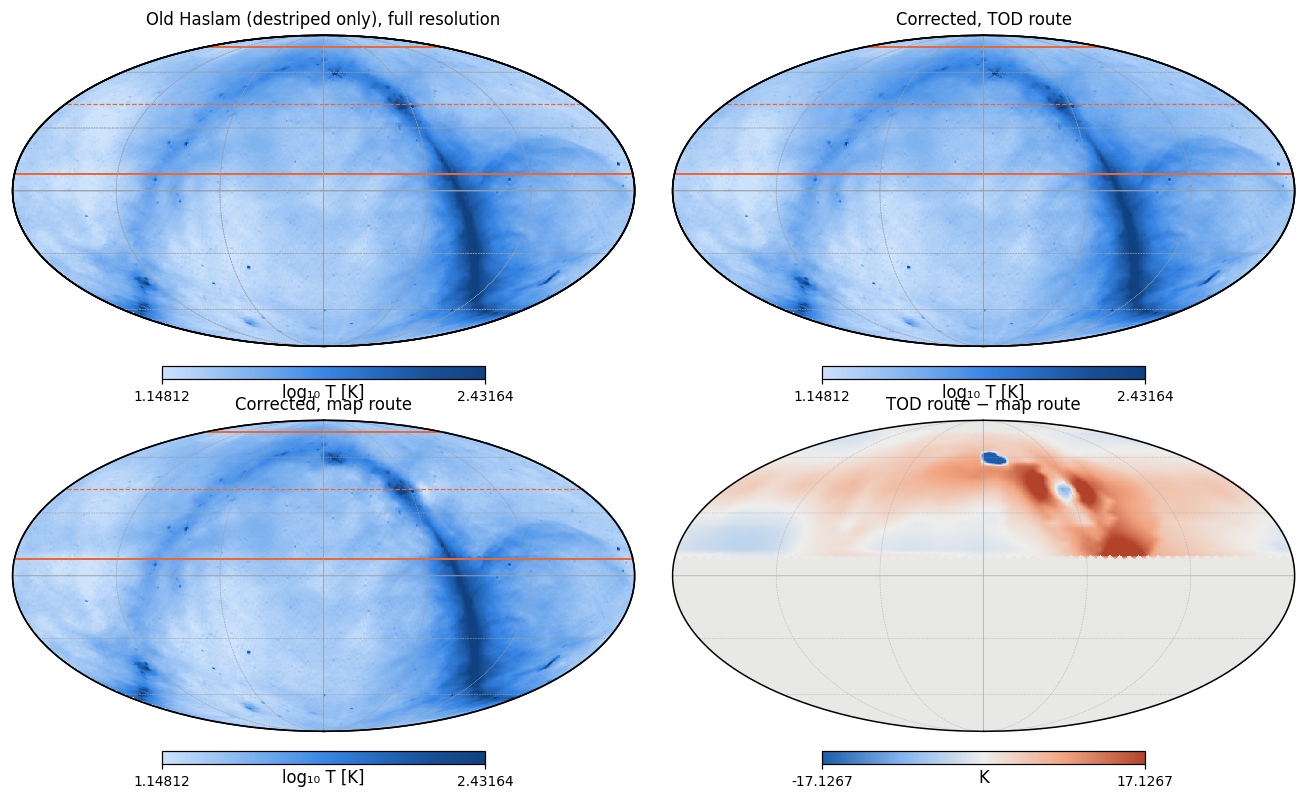

In [17]:
FULL = {"TOD route": sp.apply_full_resolution(inp, TR["delta"]),
        "map route": sp.apply_full_resolution(inp, np.where(inb, MR["delta"], 0.0))}
old_full = FULL["TOD route"]["old"]
lo, hi = np.log10(np.nanpercentile(old_full, 1)), np.log10(np.nanpercentile(old_full, 99.5))
fig = plt.figure(figsize=(12, 7.0))
for k, (title, m) in enumerate([("Old Haslam (destriped only), full resolution", old_full),
                                ("Corrected, TOD route", FULL["TOD route"]["corrected"]),
                                ("Corrected, map route", FULL["map route"]["corrected"])]):
    hp.mollview(np.log10(np.clip(m, 1e-3, None)), coord="C", sub=(2, 2, k + 1), fig=fig.number,
                cmap=SEQ, min=lo, max=hi, unit="log₁₀ T [K]", title=title, **MKW)
    hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
    stripe_lines("C")
diff = FULL["TOD route"]["corrected"] - FULL["map route"]["corrected"]
span = float(np.nanpercentile(np.abs(diff[FULL["TOD route"]["stripe"]]), 98))
hp.mollview(np.where(FULL["TOD route"]["stripe"], diff, np.nan), coord="C", sub=(2, 2, 4), fig=fig.number,
            cmap=DIV, min=-span, max=span, unit="K", title="TOD route − map route", **MKW)
hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
save(fig, "fig11_corrected_full_resolution")
plt.show()

---
## Figure 12 — T–T plots

Every pair of maps, pixel by pixel on the nside 16 grid, as CMB-subtracted RJ temperatures
(log–log). **Raw:** each map rotated into equatorial and averaged onto nside 16, with no
smoothing, so the surveys keep their own beams. **Beam-convolved:** each map matched to the
TRIS beam first. The TRIS maps are stage 1's in both, since they have no raw-beam version.
Each panel quotes the correlation of log T.

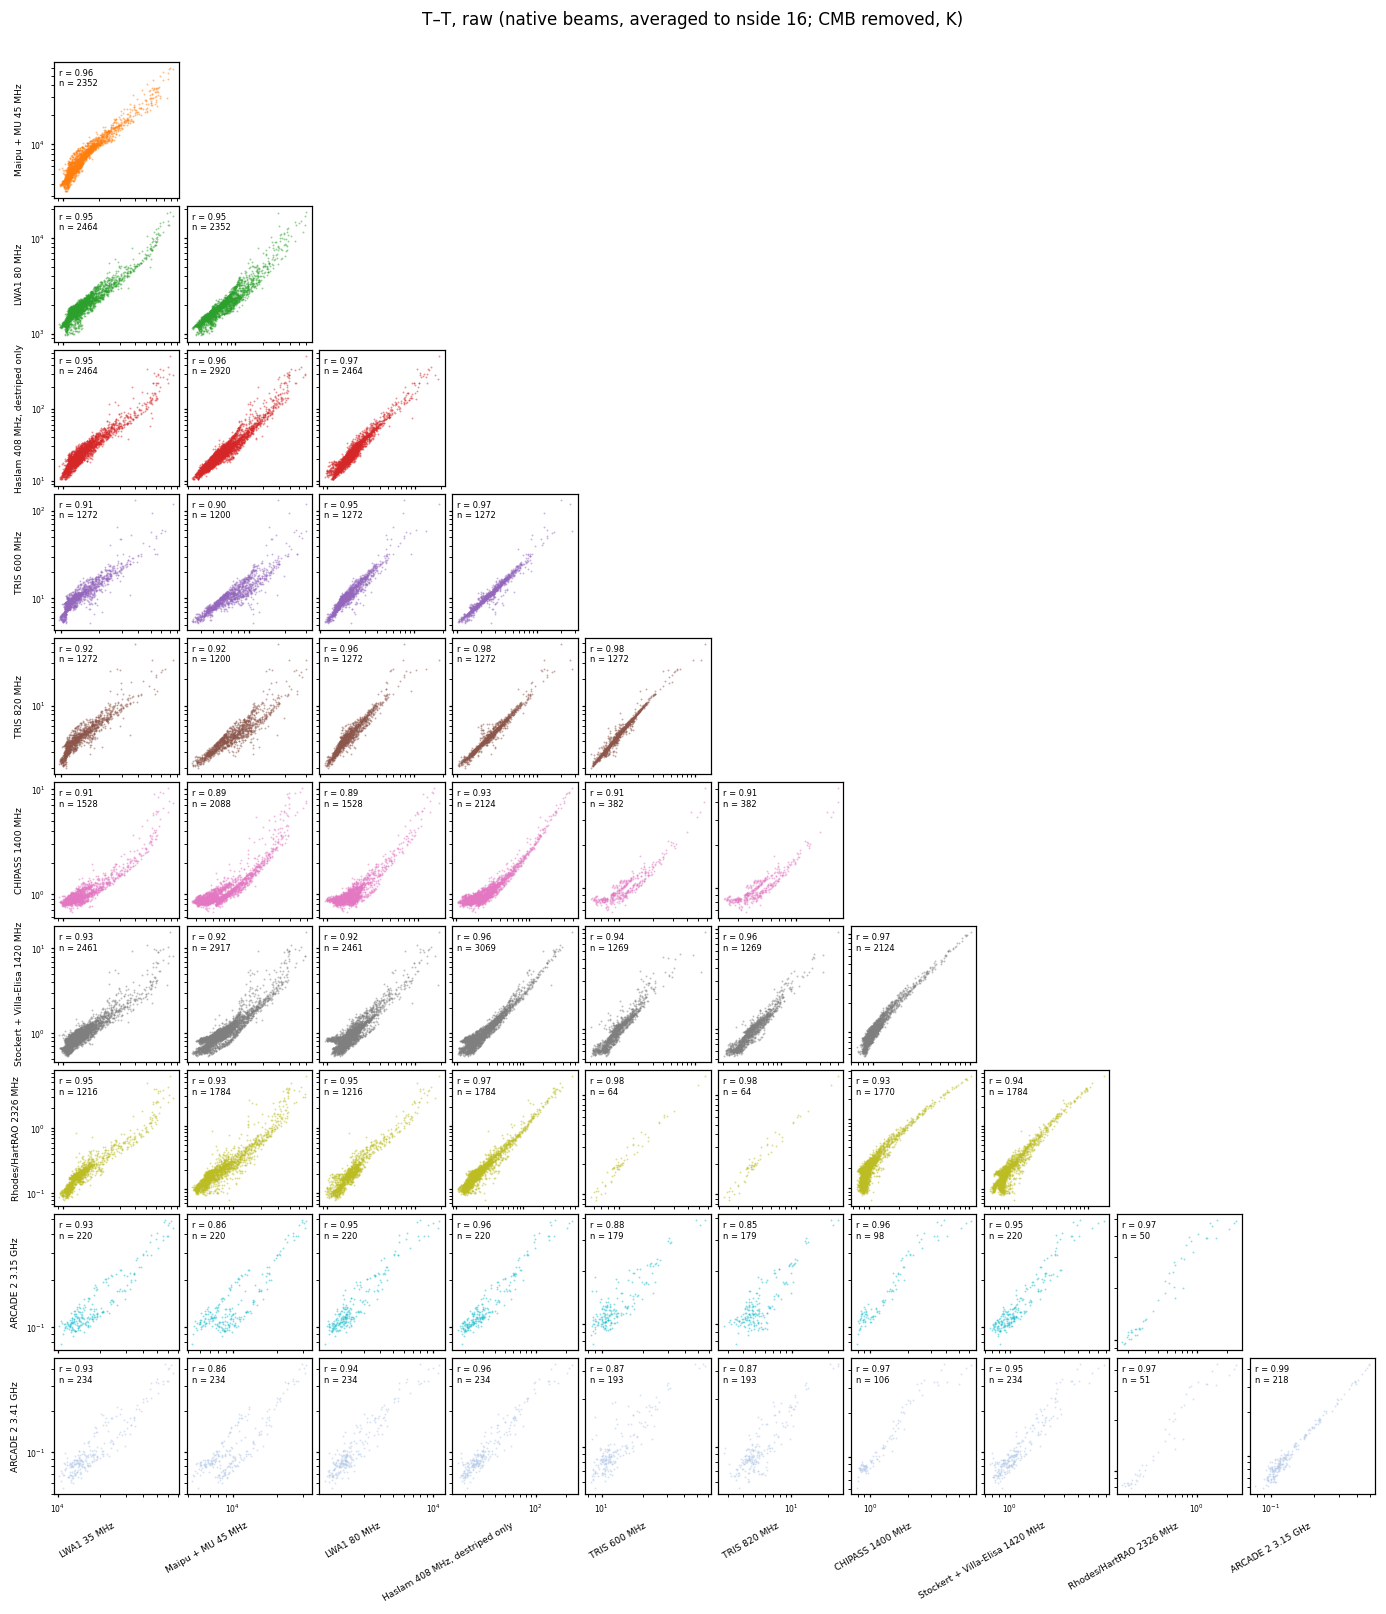

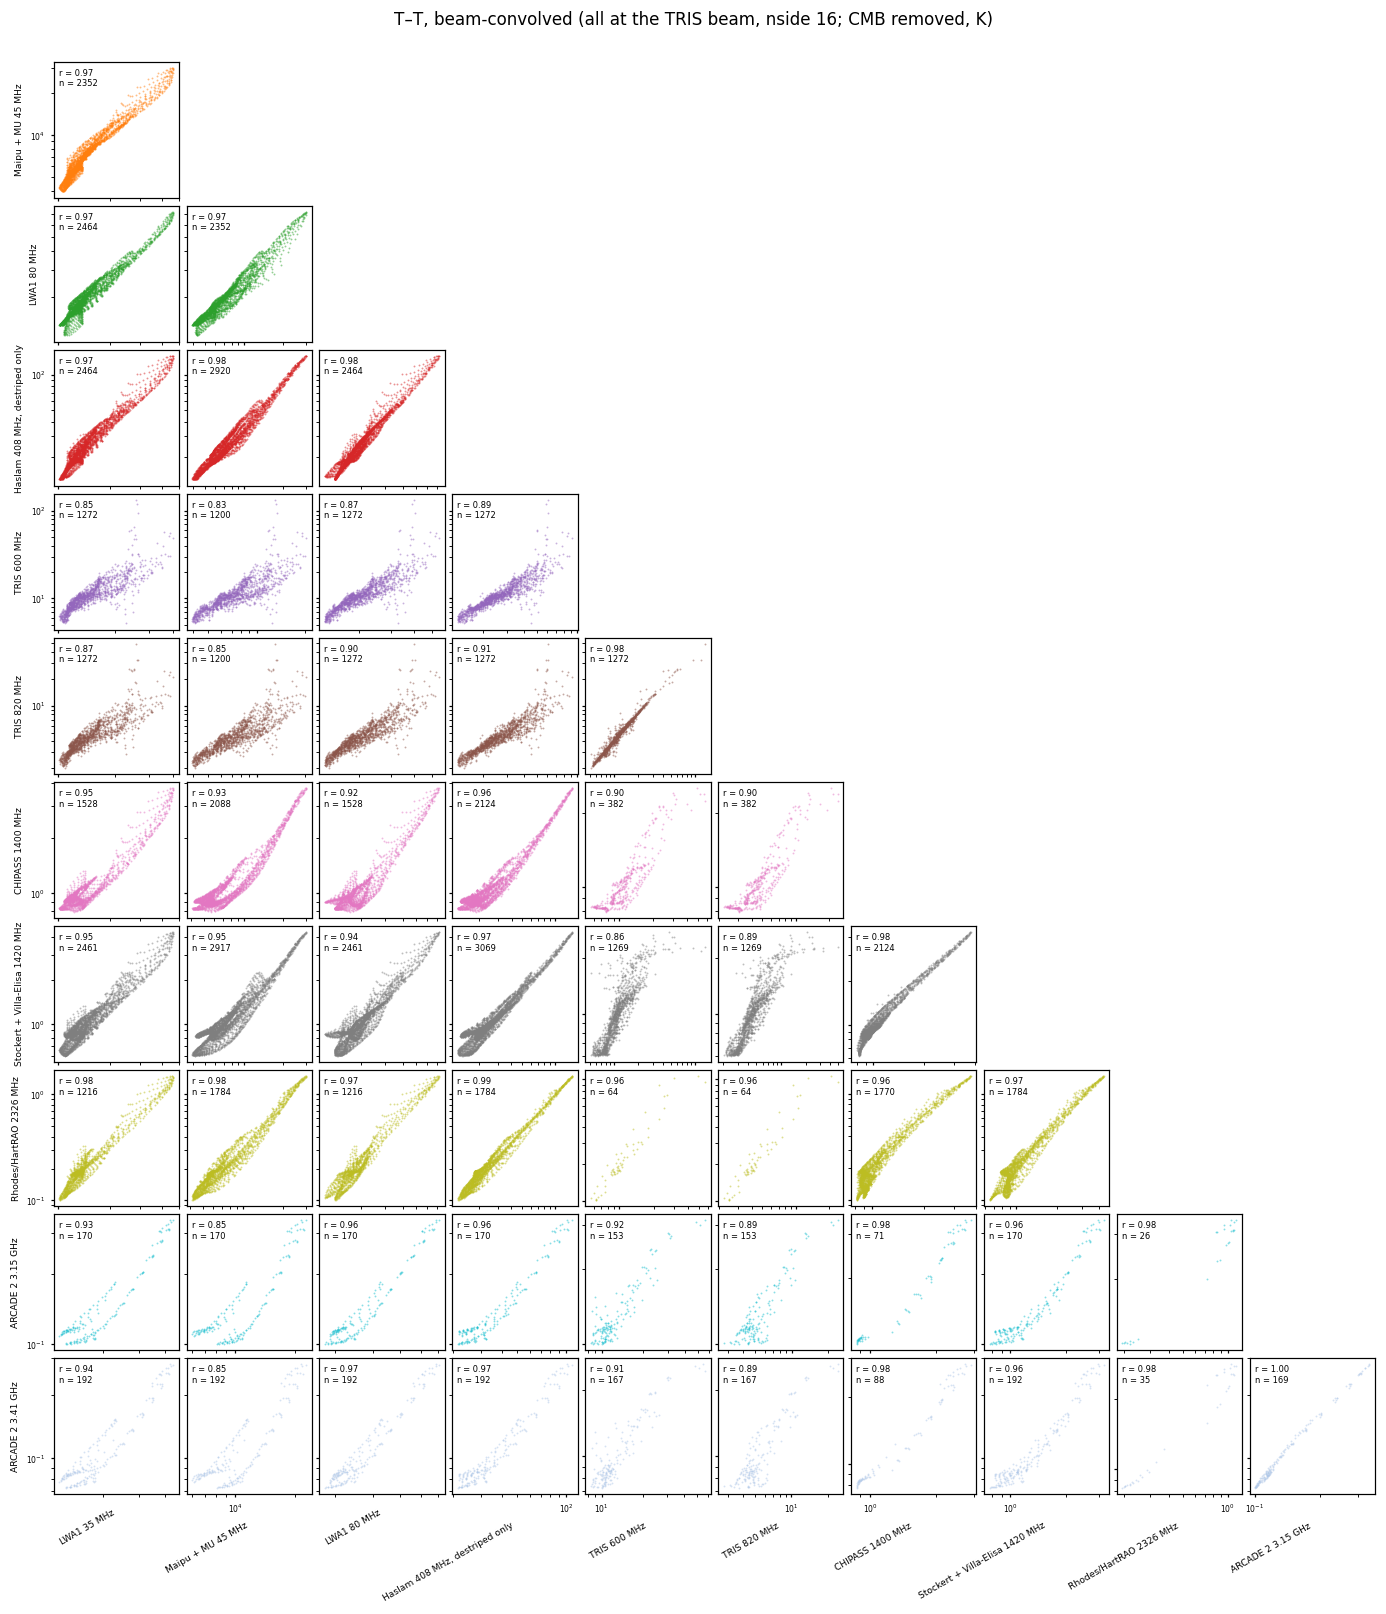

In [18]:
def tt_values(source):
    vals = {}
    for m in inp.fit_maps + [inp.target]:
        vals[m["name"]] = sky_maps.rj_excess(source[m["name"]], m)
    for f, name in zip((600, 820), TRIS_NAMES):
        nu = float(inp.stage1["effective_freq_mhz"][inp.stage1.index(f)])
        vals[name] = inp.tris_map[nu][0] - sky_maps.cmb_rj_k(nu)
    return vals

def corner(vals, title, fname):
    from matplotlib.ticker import NullFormatter, LogLocator
    names_ = [n for n in ORDER if n in vals]
    n = len(names_) - 1                       # rows: names_[1:], columns: names_[:-1]
    fig, axes = plt.subplots(n, n, figsize=(1.45 * n + 1, 1.45 * n + 1), squeeze=False)
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            yi, xj = names_[i + 1], names_[j]
            if j > i:
                ax.axis("off"); continue
            x, y = vals[xj], vals[yi]
            ok = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
            if ok.sum() > 2:
                ax.scatter(x[ok], y[ok], s=1.5, color=COLOUR[yi], alpha=0.5, lw=0)
                ax.set_xscale("log"); ax.set_yscale("log")
                r = np.corrcoef(np.log10(x[ok]), np.log10(y[ok]))[0, 1]
                ax.text(0.04, 0.95, f"r = {r:.2f}\nn = {ok.sum()}", transform=ax.transAxes,
                        fontsize=5.5, va="top")
            for axis in (ax.xaxis, ax.yaxis):
                axis.set_major_locator(LogLocator(numticks=3))
                axis.set_minor_formatter(NullFormatter())
            ax.tick_params(which="both", labelsize=5, length=2,
                           labelleft=(j == 0), labelbottom=(i == n - 1))
            if j == 0:
                ax.set_ylabel(yi.split(" (")[0], fontsize=6)
            if i == n - 1:
                ax.set_xlabel(xj.split(" (")[0], fontsize=6, rotation=30, ha="right")
    fig.suptitle(title, fontsize=11)
    fig.subplots_adjust(wspace=0.06, hspace=0.06, top=0.95)
    save(fig, fname)
    plt.show()

corner(tt_values(inp.raw16), "T–T, raw (native beams, averaged to nside 16; CMB removed, K)", "fig12a_tt_raw")
corner(tt_values(inp.grid), "T–T, beam-convolved (all at the TRIS beam, nside 16; CMB removed, K)", "fig12b_tt_beam_convolved")

---
### Summary numbers

In [19]:
print(f"target: {inp.target['name']}")
print(f"map route: {int(inb.sum())} pixels; median β {np.nanmedian(MR['beta'][inb]):+.3f}; "
      f"median χ²/dof {np.nanmedian(MR['chi2_dof'][inb]):.2f}; best fit − old: median "
      f"{np.nanmedian(MR['delta'][inb]):+.2f} K ({100 * np.nanmedian(MR['delta'][inb] / MR['old'][inb]):+.1f}%)")
print(f"TOD route: 120 samples; median β {np.nanmedian(TR['beta']):+.3f}; median χ²/dof "
      f"{np.nanmedian(TR['chi2_dof']):.2f}; best fit − old along the ring: median "
      f"{np.nanmedian(TR['delta_tod']):+.2f} K ({100 * np.nanmedian(TR['delta_tod'] / TR['target_tod']):+.1f}%)")
print(f"figures written to {OUT}")

target: Haslam 408 MHz, destriped only
map route: 1272 pixels; median β -2.598; median χ²/dof 1.48; best fit − old: median -0.13 K (-0.4%)
TOD route: 120 samples; median β -2.549; median χ²/dof 4.23; best fit − old along the ring: median +3.84 K (+12.6%)
figures written to /Users/user/Documents/Codes/project3/moonrunes/outputs/paper_plots
